Este script es del curso de Forex (trading algoritmico)
   Implementa una estrategia de cruce de dos medias móviles simples (SMA:
   SMA 50 : media móvil corta
   SMA 200 : media móvil larga
   La estrategia consiste en:
   asumir largo (+1) cuando SMA 50 cruce hacia arriba de SMA 200
   asumir corto (-1) cuando SMA 50 cruce hacia abajo de de SMA 200
   Calcular rendimientos y comparar con B/H 


In [63]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.trend import EMAIndicator
plt.style.use('seaborn-v0_8-whitegrid')


# lectura de los datos
data = pd.read_csv("datos_historia.csv", parse_dates=["Date"], index_col = "Date")
data.head()

,price
Date,
2023-01-01 00:04:59.999,10.00
2023-01-01 00:09:59.999,9.96
2023-01-01 00:14:59.999,9.95
2023-01-01 00:19:59.999,9.97
2023-01-01 00:24:59.999,9.98


In [59]:
# períodos de las medias móviles

#sma_s = 9
#sma_l = 21

ema_s = 9
ema_l = 21


In [64]:
# calcular las dos medias y agregarlas como columnas (SMA_S, SMA_L) al dataframe data
#data['SMA_S'] = data.price.rolling(sma_s).mean()
#data['SMA_L'] = data.price.rolling(sma_l).mean()

# Calcular EMAs
data['EMA_S'] = EMAIndicator(data['price'], window=9).ema_indicator()
data['EMA_L'] = EMAIndicator(data['price'], window=21).ema_indicator()
data

,price,EMA_S,EMA_L
Date,,,
2023-01-01 00:04:59.999,10.00,NaN,NaN
2023-01-01 00:09:59.999,9.96,NaN,NaN
2023-01-01 00:14:59.999,9.95,NaN,NaN
2023-01-01 00:19:59.999,9.97,NaN,NaN
2023-01-01 00:24:59.999,9.98,NaN,NaN
...,...,...,...
2023-12-30 23:44:59.999,101.83,101.952094,102.088903
2023-12-30 23:49:59.999,101.96,101.953675,102.077184
2023-12-30 23:54:59.999,101.66,101.894940,102.039258


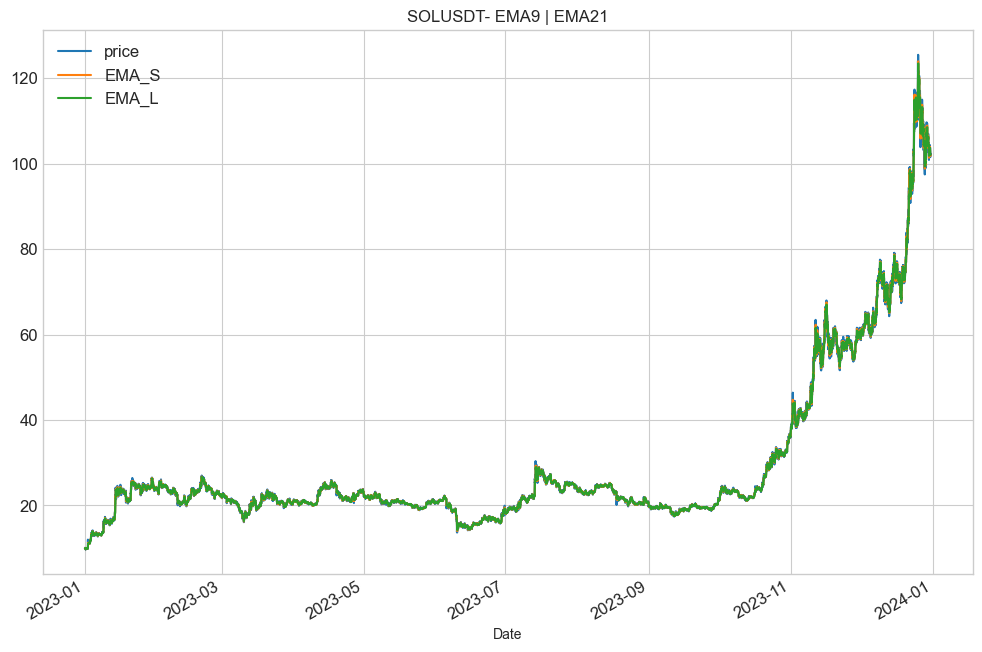

In [65]:
# graficar los datos
data.plot(figsize = (12, 8), title = "SOLUSDT- EMA{} | EMA{}".format(ema_s, ema_l),fontsize = 12)
plt.legend(fontsize = 12)
plt.show()

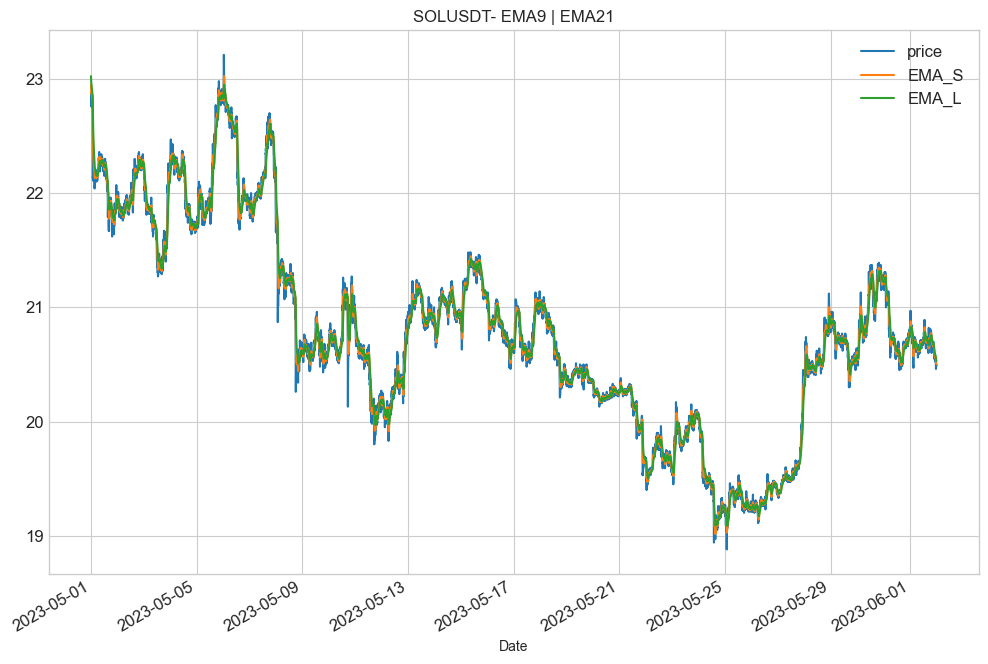

In [66]:
# graficar solo un mes par hacer zoom
data['2023-05-01':'2023-06-01'].plot(figsize = (12, 8), title = "SOLUSDT- EMA{} | EMA{}".format(ema_s, ema_l),fontsize = 12)
plt.legend(fontsize = 12)
plt.show()

In [67]:
# crea una nueva columna (position) para luego calcular los rendimientos de
# la estrategia a partir de esta. Esta columna define la estratagie de cruces.
data['position'] = np.where(data['EMA_S'] > data['EMA_L'], 1, -1)
data

,price,EMA_S,EMA_L,position
Date,,,,
2023-01-01 00:04:59.999,10.00,NaN,NaN,-1
2023-01-01 00:09:59.999,9.96,NaN,NaN,-1
2023-01-01 00:14:59.999,9.95,NaN,NaN,-1
2023-01-01 00:19:59.999,9.97,NaN,NaN,-1
2023-01-01 00:24:59.999,9.98,NaN,NaN,-1
...,...,...,...,...
2023-12-30 23:44:59.999,101.83,101.952094,102.088903,-1
2023-12-30 23:49:59.999,101.96,101.953675,102.077184,-1
2023-12-30 23:54:59.999,101.66,101.894940,102.039258,-1


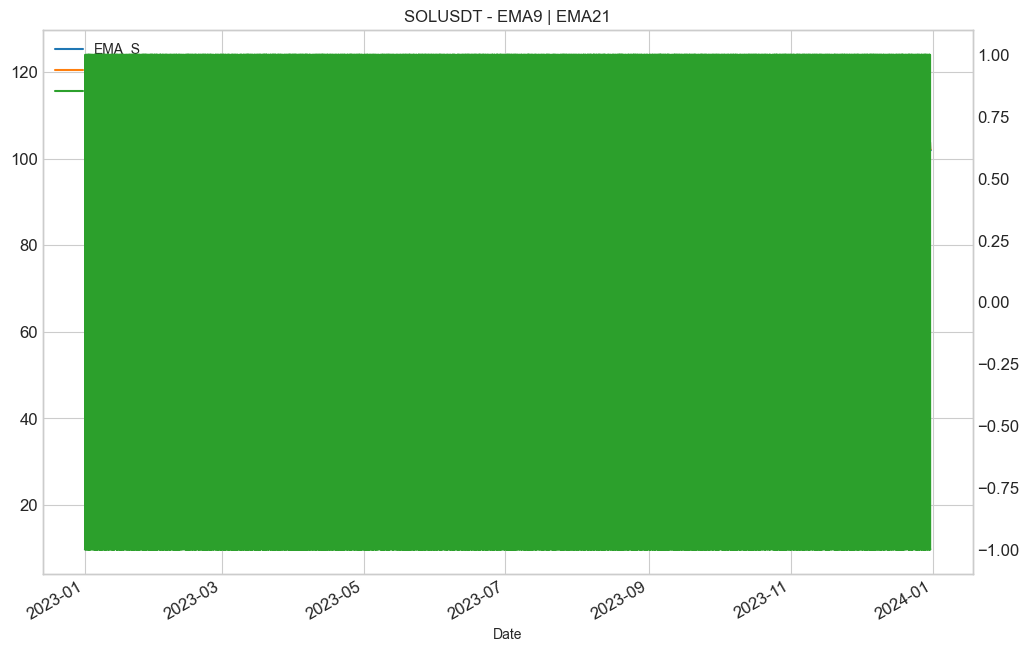

In [68]:
# graficar las EMAs con la señal biestable de compra-venta
data.loc[:, ['EMA_S', 'EMA_L', 'position']].plot(figsize=(12, 8), \
        fontsize = 12, secondary_y = 'position', \
        title= "SOLUSDT - EMA{} | EMA{}".format(ema_s, ema_l))
plt.show()


In [69]:
# graficar solo un mes para realizar zoom a la gráfica
"""
data.loc['2023-01-01':'2023-01-31',['SMA_S', 'SMA_L', 'position']].plot(figsize=(12, 8), \
        fontsize = 12, secondary_y = 'position', \
        title= "SOLUSDT - SMA{} | SMA{}".format(sma_s, sma_l))
plt.show()
"""
datos_mes = data.loc['2023-10']
datos_mes



,price,EMA_S,EMA_L,position
Date,,,,
2023-10-01 00:04:59.999,21.30,21.369102,21.375460,-1
2023-10-01 00:09:59.999,21.32,21.359282,21.370418,-1
2023-10-01 00:14:59.999,21.39,21.365425,21.372198,-1
2023-10-01 00:19:59.999,21.37,21.366340,21.371998,-1
2023-10-01 00:24:59.999,21.33,21.359072,21.368180,-1
...,...,...,...,...
2023-10-31 23:39:59.999,38.25,37.941851,37.740697,1
2023-10-31 23:44:59.999,38.37,38.027481,37.797907,1
2023-10-31 23:49:59.999,38.47,38.115984,37.859006,1


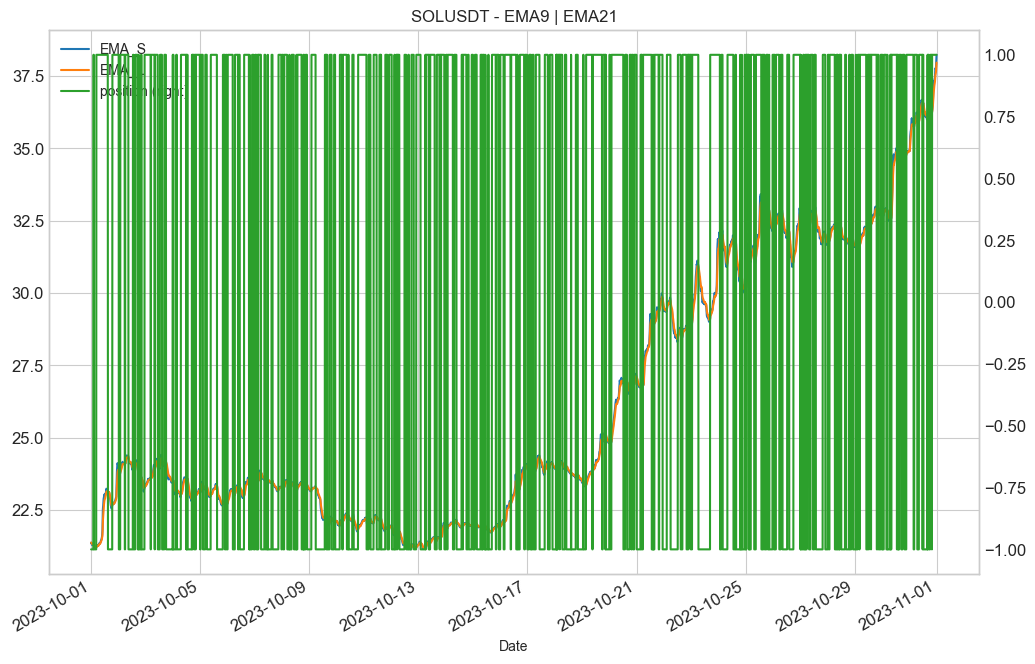

In [70]:
datos_mes.loc[:,['EMA_S', 'EMA_L', 'position']].plot(figsize=(12, 8), \
        fontsize = 12, secondary_y = 'position', \
        title= "SOLUSDT - EMA{} | EMA{}".format(ema_s, ema_l))
plt.show()

calcular los rendimientos diarios con el logaritmo natural
esta operación consiste en calcular el rendimiento como el 
cuociente entre el precio del dia de hoy entre el precio
del dia de ayer y luego sacar el ln del resultado
esto corresponde a la estrategia B/H, es decir, compré
al inicio del período de los datos de precios históricos
y mantuve la inversión hasta el último día del período
considerado

In [71]:


data["return"] = np.log(data.price.div(data.price.shift(1)))


# a continuación se calculan los rendimientos de esta estrategia
# de cruce de medias móviles mediante el producto de la posición
# del día anterior por el rendimiento del día actual 
data["strategy"] = data.position.shift(1) * data["return"]

data.dropna(inplace=True)



In [72]:
data[["return", "strategy"]].sum() #realización absoluta



return      2.32063
strategy    0.28453
dtype: float64

In [73]:
data[["return", "strategy"]].sum().apply(np.exp)

return      10.182090
strategy     1.329137
dtype: float64

In [74]:
data[["return", "strategy"]].mean() * 252 # realización anualizada



return      0.005580
strategy    0.000684
dtype: float64

In [75]:
data[["return", "strategy"]].std() * np.sqrt(252) # riesgo anualizado




return      0.050197
strategy    0.050198
dtype: float64

In [76]:
data["creturn"] = data["return"].cumsum().apply(np.exp)
data["cstrategy"] = data["strategy"].cumsum().apply(np.exp)



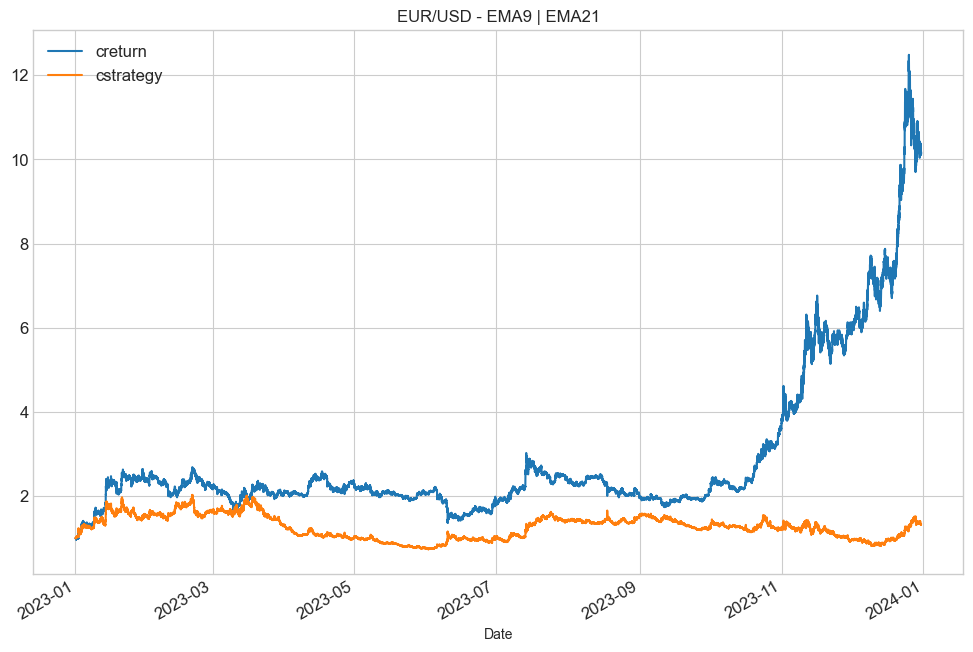

In [77]:
data[["creturn", "cstrategy"]].plot(figsize = (12, 8), title = "EUR/USD - EMA{} | EMA{}".format(9, 21), fontsize = 12)
plt.legend(fontsize = 12)
plt.show()




In [78]:
outperf = data.cstrategy.iloc[-1] - data.creturn.iloc[-1]
outperf


np.float64(-8.852952705371502)